# Trailing Stop Loss Impact Analysis
The goal of this notebook is to identify the ideal trailing SL level based on historically similar events

In [20]:
from util.trailing_stop import simulate_trailing_stop
from datetime import datetime, timezone
from curl_cffi import requests
import matplotlib.pyplot as plt
import re

## Collecting test cases

In [2]:
params = {
    "os": "web",
    "category": "trade",
    "page": 1,
    "per_page": 20,
}
headers = {
    "Accept": "application/json",
    "Referer": "https://upbit.com",
    "Accept-Language": "en-US,en;q=0.9,ko;q=0.9",
}

response = requests.get(
    "https://api-manager.upbit.com/api/v1/announcements",
    headers=headers,
    params=params,
    impersonate="chrome",
    timeout=10,
)

if response.status_code != 200:
    raise RuntimeError(
        f"Upbit notices request failed with status {response.status_code}: "
        f"{response.text[:500]}"
    )

data = response.json()
notices = [
    notice
    for notice in data.get("data", {}).get("notices", [])
    if ("Market Support".casefold() in notice.get("title", "").casefold()) and 
        ("KRW".casefold() in notice.get("title", "").casefold())
]

test_cases = {}
for n in notices: 
    ticker = re.search(r"\(([A-Z0-9]+)\)", n["title"]).group(1)
    upbit_time = datetime.fromisoformat(n["first_listed_at"])
    test_cases[ticker] = upbit_time.astimezone(timezone.utc)

In [3]:
test_cases

{'DRV': datetime.datetime(2026, 7, 14, 5, 15, 2, tzinfo=datetime.timezone.utc),
 'OPG': datetime.datetime(2026, 7, 7, 4, 39, 48, tzinfo=datetime.timezone.utc),
 'AI': datetime.datetime(2026, 6, 30, 3, 0, 55, tzinfo=datetime.timezone.utc),
 'ARX': datetime.datetime(2026, 6, 23, 2, 0, tzinfo=datetime.timezone.utc),
 'RE': datetime.datetime(2026, 6, 19, 9, 0, 2, tzinfo=datetime.timezone.utc),
 'SPX': datetime.datetime(2026, 6, 16, 2, 12, 26, tzinfo=datetime.timezone.utc),
 'BABY': datetime.datetime(2026, 6, 5, 9, 30, tzinfo=datetime.timezone.utc)}

## Testing SL Distance

In [34]:
def plot_line_chart(x:list, y:list):
    fig, ax = plt.subplots(figsize=(10, 5.5))

    # Line and markers
    ax.plot(
        x,
        y,
        linewidth=1.5,
        marker="o",
        markersize=7,
    )

    # Labels and title
    ax.set_title("Trailing SL Distance VS % PnL", fontsize=16, fontweight="bold", pad=15)
    ax.set_xlabel("Trailing SL %", fontsize=11)
    ax.set_ylabel("PnL % Return", fontsize=11)

    # Clean visual styling
    ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.35)
    ax.legend(frameon=False)

    fig.tight_layout()
    plt.show()

In [17]:
ticker = "OPG"
entry_time_utc = test_cases[ticker]

distance_list = []
pnl_list = []
for i in range(1, 30, 1):
    pnl_percent = simulate_trailing_stop(ticker, entry_time_utc, i)
    distance_list.append(i)
    pnl_list.append(pnl_percent)


C:\Users\maxma\AppData\Local\Temp\ipykernel_4560\2310101729.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


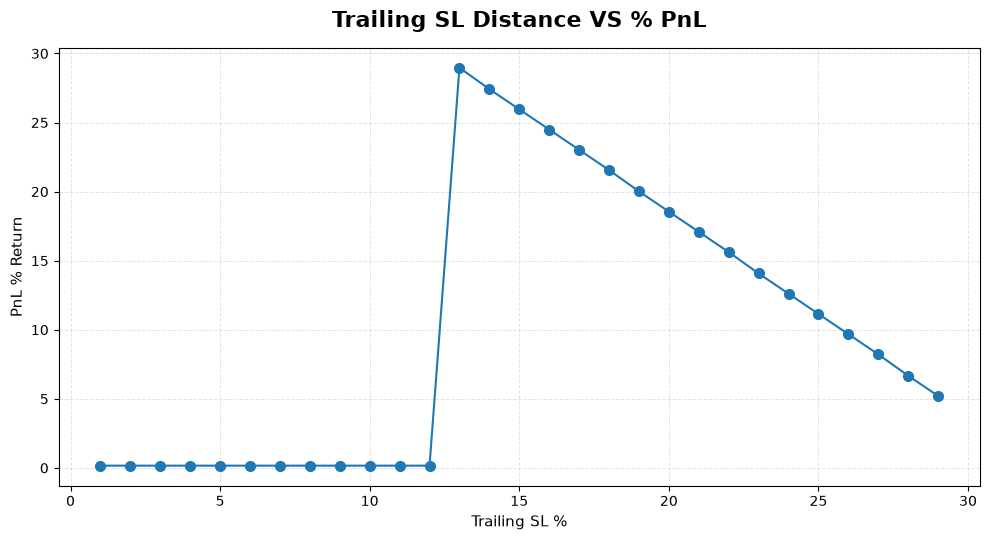

In [35]:
plot_line_chart(distance_list, pnl_list)